In [ ]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True
# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")
# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [3]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\_aromatic_2025_10656_CHNOS.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
162,1-[p-Methylsulfonylphenylazo[3-carbamylgunidine,C9H12N6O3S,284,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,C[S](=O)(=O)c1ccc(NN=NC(N)=NC(N)=O)cc1,CHNOS
264,"4-Toluenesulfonamide, 3-nitro-N-(1-iminopropyl)-",C10H13N3O4S,271,129958-15-2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCC(=N)N[S](=O)(=O)c1ccc(C)cc1[N+]([O-])=O,CHNOS
300,N-[4-(N-Methyl)acetamido-2-nitrophenyl]-p-tolu...,C16H17N3O5S,363,10228-31-6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CN(C(C)=O)c1ccc(N[S](=O)(=O)c2ccc(C)cc2)c(c1)[...,CHNOS
305,2-Acetamido-5-p-tosylamido-p-benzoquinone,C15H14N2O5S,334,56393-59-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(=O)NC1=CC(=O)C(=CC1=O)N[S](=O)(=O)c2ccc(C)cc2,CHNOS
358,"4-Hydroxy-3-phenyl-4,6,6-trimethylhexahydropyr...",C13H18N2OS,250,74628-49-2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC1(C)CC(C)(O)N(C(=S)N1)c2ccccc2,CHNOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182290,"4H-Cyclopenta[b]thiophene-3-carboxylic acid, 2...",C10H13NO2S,211,4815-29-6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(=O)c1c(N)sc2CCCc12,CHNOS
182446,1-(Alpha-acetamidotoluene-p-sulfonyl)-3-hexylurea,C16H25N3O4S,355,88637-18-7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCCCNC(=O)N[S](=O)(=O)c1ccc(CNC(C)=O)cc1,CHNOS
182447,1-(Alpha-acetamidotoluene-p-sulfonyl)-3-propyl...,C13H19N3O4S,313,91881-30-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCNC(=O)N[S](=O)(=O)c1ccc(CNC(C)=O)cc1,CHNOS
182448,1-((1-Acetamidoethyl)benzene-p-sulfonyl)-3-but...,C15H23N3O4S,341,92728-32-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCNC(=O)N[S](=O)(=O)c1ccc(cc1)C(C)NC(C)=O,CHNOS


In [ ]:
import deepchem as dc
import selfies as sf
import pandas as pd
X = ms.iloc[:, 4:604]     # spectra
y = ms.iloc[:, 605]       # smiles

se = []
dr = []  # list of indices to drop
c = 0

# Check all SMILES and filter out invalid/unsupported ones
for i in y:
    try:
        selfies_str = sf.encoder(i)
        se.append(selfies_str)
        if '.' in selfies_str:  # check for multi-molecule SMILES
            dr.append(c)
    except Exception as e:
        # Add to drop list if encoding fails (chemically invalid SMILES)
        dr.append(c)
    c += 1

# Drop problematic rows from original DataFrame
ms_cleaned = ms.drop(index=ms.index[dr]).reset_index(drop=True)

# Extract cleaned spectra and SMILES
X_clean = ms_cleaned.iloc[:, 4:604].to_numpy()
y_clean = ms_cleaned.iloc[:, 605].to_numpy()

# Create DeepChem dataset
ds = dc.data.DiskDataset.from_numpy(X_clean, y_clean)
ds

<DiskDataset X.shape: (np.int64(10656), np.int64(600)), y.shape: (np.int64(10656),), w.shape: (np.int64(10656),), task_names: [0]>

In [6]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C-1]': 2,
 '[#C]': 3,
 '[#N]': 4,
 '[/-Ring1]': 5,
 '[/C]': 6,
 '[/N]': 7,
 '[/O]': 8,
 '[/SH0]': 9,
 '[/S]': 10,
 '[=Branch1]': 11,
 '[=Branch2]': 12,
 '[=CH0]': 13,
 '[=CH2]': 14,
 '[=C]': 15,
 '[=N+1]': 16,
 '[=N-1]': 17,
 '[=N]': 18,
 '[=O]': 19,
 '[=Ring1]': 20,
 '[=Ring2]': 21,
 '[=SH0]': 22,
 '[=S]': 23,
 '[Branch1]': 24,
 '[Branch2]': 25,
 '[C@@H1]': 26,
 '[C@@]': 27,
 '[C@H1]': 28,
 '[C@]': 29,
 '[CH0]': 30,
 '[CH1]': 31,
 '[CH2]': 32,
 '[C]': 33,
 '[N+1]': 34,
 '[N-1]': 35,
 '[NH1]': 36,
 '[N]': 37,
 '[O+1]': 38,
 '[O-1]': 39,
 '[O]': 40,
 '[P]': 41,
 '[Ring1]': 42,
 '[Ring2]': 43,
 '[S@@]': 44,
 '[S@]': 45,
 '[SH0]': 46,
 '[S]': 47,
 '[\\-Ring1]': 48,
 '[\\C]': 49,
 '[\\N+1]': 50,
 '[\\N]': 51,
 '[\\O]': 52,
 '[\\S]': 53,
 '[nop]': 54}

In [7]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [8]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.9,
    frac_valid=0,
    frac_test=0.1,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 9504
📦 Validation set size: 0
📦 Test set size: 1152


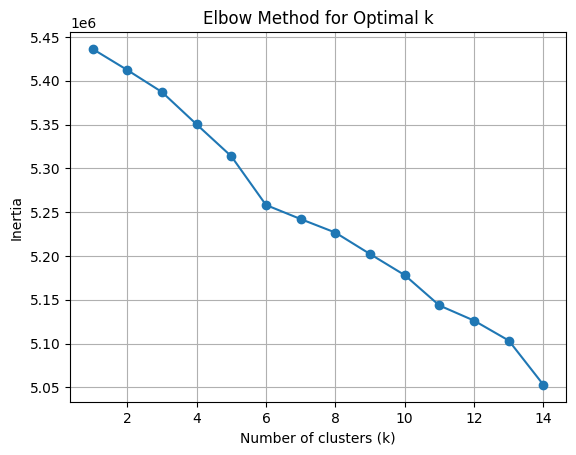

🔍 Elbow point detected at k = 1


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [10]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=3,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=3)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\spli

In [11]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(3):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (1325, 600)
Cluster 1 shape: (1295, 600)
Cluster 2 shape: (6884, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\spli

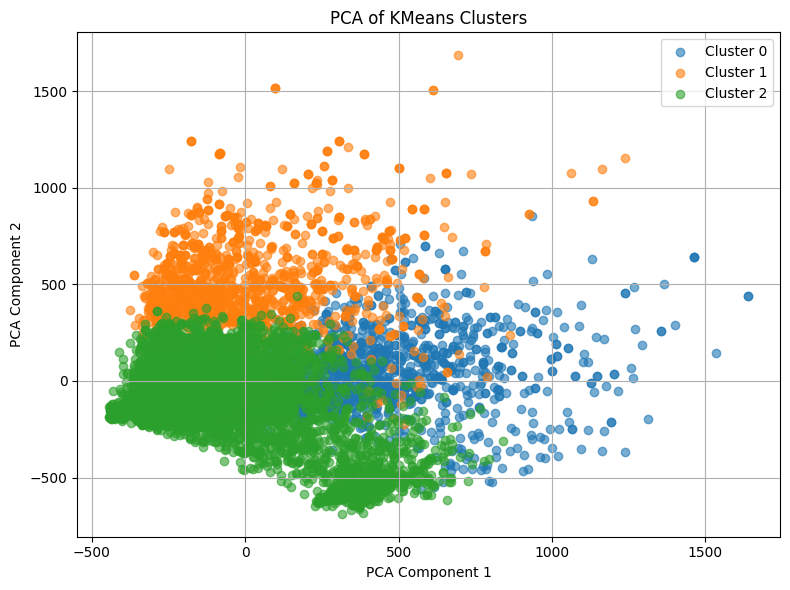

In [12]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=3)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [13]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [14]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")





✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_

Cluster 0: size = 143, shape = (143, 600)
Cluster 1: size = 186, shape = (186, 600)
Cluster 2: size = 823, shape = (823, 600)


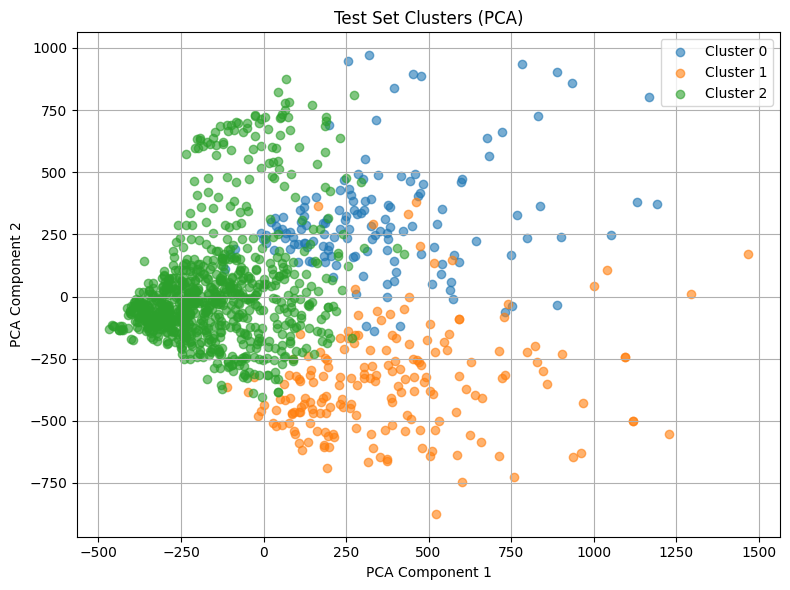

In [15]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(3):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 0.191419
Epoch 2/100 - Loss: 0.032936
Epoch 3/100 - Loss: 0.030774
Epoch 4/100 - Loss: 0.029652
Epoch 5/100 - Loss: 0.028445
Epoch 6/100 - Loss: 0.027161
Epoch 7/100 - Loss: 0.025633
Epoch 8/100 - Loss: 0.023944
Epoch 9/100 - Loss: 0.022795
Epoch 10/100 - Loss: 0.021442
Epoch 11/100 - Loss: 0.019971
Epoch 12/100 - Loss: 0.018832
Epoch 13/100 - Loss: 0.017405
Epoch 14/100 - Loss: 0.016248
Epoch 15/100 - Loss: 0.014525
Epoch 16/100 - Loss: 0.014025
Epoch 17/100 - Loss: 0.012980
Epoch 18/100 - Loss: 0.011999
Epoch 19/100 - Loss: 0.011281
Epoch 20/100 - Loss: 0.010353
Epoch 21/100 - Loss: 0.009524
Epoch 22/100 - Loss: 0.008677
Epoch 23/100 - Loss: 0.008351
Epoch 24/100 - Loss: 0.007856
Epoch 25/100 - Loss: 0.007362
Epoch 26/100 - Loss: 0.006869
Epoch 27/100 - Loss: 0.006366
Epoch 28/100 - Loss: 0.006054
Epoch 29/100 - Loss: 0.005363
Epoch 30/100 - Loss: 0.005407
Epoch 31/100 - Loss: 0.005017
Epoch 32/100 - Loss: 0.004820
Epoch 33/100 - Loss: 0.004547
Epoch 34/100 - Loss

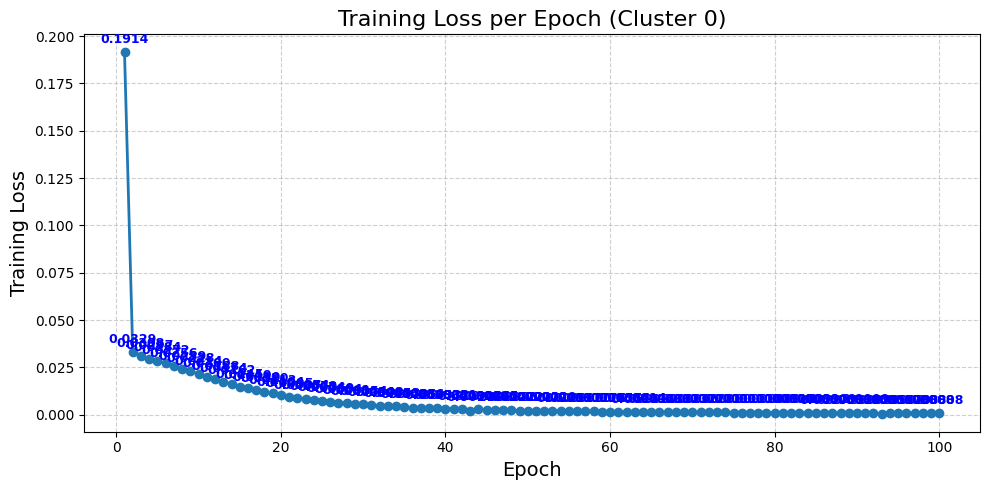

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\models_\model0000


In [16]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [17]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [18]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (143, 3850, 2)
Example prediction: [[1.00000000e+00 5.77880972e-12]
 [1.00000000e+00 2.12706412e-13]
 [1.00000000e+00 3.50299997e-12]
 ...
 [1.00000000e+00 1.60002983e-11]
 [1.00000000e+00 1.34009175e-11]
 [8.36503176e-14 1.00000000e+00]]


In [19]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [20]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [21]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: CC1=CC=CC=C1CSCC(=O)N/N=C/C2=CC=C(OCC=C)C=C2 | True: CC1=CC=CC=C1CSCC(=O)N/N=C/C2=CC=C(OCC=C)C=C2 | Tanimoto: 1.000
[1] Pred: CCCCSC=1ON=C(C=1)C2=CC=CC=C2 | True: CCCCSC=1ON=C(C=1)C2=CC=CC=C2 | Tanimoto: 1.000
[2] Pred: COC(=O)CNC(=CC(=S)C1=CC=CC=C1)C2=CC=CC=C2 | True: COC(=O)CNC(=CC(=S)C1=CC=CC=C1)C2=CC=CC=C2 | Tanimoto: 1.000
[3] Pred: COC1=C2C=C(COC2)C1[SH0]CC=NCNC=CCCN | True: CCC(C)(N[SH0](=O)(=O)C1=CC(OC)=CC=C1OC)C#C | Tanimoto: 0.210
[4] Pred: C1CCCCC1CC=CC=CCCCC=O | True: CC1=CC=2[NH1]C(SCC(=O)NC3=CC=CC=C3C(O)=O)=NC=2C=C1C | Tanimoto: 0.051
[5] Pred: CCC=CC=CCSCC(=C)C=CN=C | True: CCOC1=CC=C(C=C1)C=NC=2SC3=CC(=CC=C3N=2)C(=O)OC | Tanimoto: 0.065
[6] Pred: [SH0](C=C=O)NC[SH0]1=CC=CCC1=CO | True: NC1=CC=C(C=C1)[SH0](=O)(=O)C2=CC=C(NC3=CC=C(C=C3)[SH0](N)(=O)=O)C(N)=C2 | Tanimoto: 0.113
[7] Pred: CCCC=O | True: N[SH0](=O)(=O)C1=CC=C(CNC2=NC=NC=3N(CC4=CC=C(C=C4)[SH0](N)(=O)=O)C=NC2=3)C=C1 | Tanimoto: 0.006
[8] Pred: CC=CC=CCCCC=C | True: N[SH0](=O)(=O)C1=CC=C(N\N=C\[N+1]([O

Epoch 1/100 - Loss: 0.226674
Epoch 2/100 - Loss: 0.034369
Epoch 3/100 - Loss: 0.031694
Epoch 4/100 - Loss: 0.030067
Epoch 5/100 - Loss: 0.028478
Epoch 6/100 - Loss: 0.026865
Epoch 7/100 - Loss: 0.025526
Epoch 8/100 - Loss: 0.023763
Epoch 9/100 - Loss: 0.022694
Epoch 10/100 - Loss: 0.021263
Epoch 11/100 - Loss: 0.019848
Epoch 12/100 - Loss: 0.018517
Epoch 13/100 - Loss: 0.017193
Epoch 14/100 - Loss: 0.016100
Epoch 15/100 - Loss: 0.014965
Epoch 16/100 - Loss: 0.013743
Epoch 17/100 - Loss: 0.012614
Epoch 18/100 - Loss: 0.011834
Epoch 19/100 - Loss: 0.010958
Epoch 20/100 - Loss: 0.010080
Epoch 21/100 - Loss: 0.009409
Epoch 22/100 - Loss: 0.008606
Epoch 23/100 - Loss: 0.008016
Epoch 24/100 - Loss: 0.007542
Epoch 25/100 - Loss: 0.006760
Epoch 26/100 - Loss: 0.006321
Epoch 27/100 - Loss: 0.005845
Epoch 28/100 - Loss: 0.005589
Epoch 29/100 - Loss: 0.005068
Epoch 30/100 - Loss: 0.004659
Epoch 31/100 - Loss: 0.004286
Epoch 32/100 - Loss: 0.004131
Epoch 33/100 - Loss: 0.003816
Epoch 34/100 - Loss

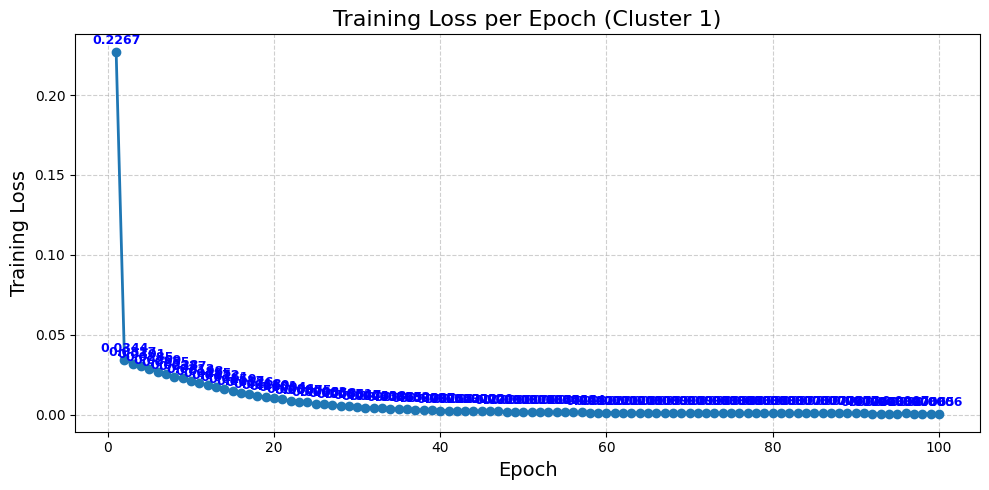

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with seed 123\models_\model1111


In [22]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [23]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (186, 3850, 2)
Example prediction: [[1.0000000e+00 6.2245126e-11]
 [1.0000000e+00 1.2510355e-09]
 [1.0000000e+00 5.8645255e-10]
 ...
 [1.0000000e+00 1.5639783e-12]
 [1.0000000e+00 7.0901063e-11]
 [1.1783471e-10 1.0000000e+00]]
[0] Pred: CC1(C)CC(C)(O)N(C(=S)N1)C2=CC=CC=C2 | True: CC1(C)CC(C)(O)N(C(=S)N1)C2=CC=CC=C2 | Tanimoto: 1.000
[1] Pred: CC(=O)NC1=CC=C(C=C1)[SH0](=O)(=O)NCC2=CC=CN=C2 | True: CC(=O)NC1=CC=C(C=C1)[SH0](=O)(=O)NCC2=CC=CN=C2 | Tanimoto: 1.000
[2] Pred: CN1CCN(CC1)C2=CC=C(C=C2)[SH0](=O)(=O)C3=CC=C(N)C=C3 | True: CN1CCN(CC1)C2=CC=C(C=C2)[SH0](=O)(=O)C3=CC=C(N)C=C3 | Tanimoto: 1.000
[3] Pred: CC(=O)OC1=CC(OC(C)=O)=CC(C=NNC(N)=S)=C1 | True: CC(=O)OC1=CC(OC(C)=O)=CC(C=NNC(N)=S)=C1 | Tanimoto: 1.000
[4] Pred: CC(=O)OCC1C(CCSC(C)=O)OC(C1OC(C)=O)C2N=NC3=C(NC(=O)C4=CC=CC=C4)N=CN=C23 | True: CC(=O)OCC1C(CCSC(C)=O)OC(C1OC(C)=O)C2N=NC3=C(NC(=O)C4=CC=CC=C4)N=CN=C23 | Tanimoto: 1.000
[5] Pred: CCOC(=O)C1=C(NC(C)=O)SSC1=S | True: CCOC(=O)C1=C(NC(C)=O)SSC1=S | Tan

---------------------------------------------------

Epoch 1/100 - Loss: 0.063268
Epoch 2/100 - Loss: 0.030460
Epoch 3/100 - Loss: 0.028843
Epoch 4/100 - Loss: 0.027963
Epoch 5/100 - Loss: 0.026887
Epoch 6/100 - Loss: 0.025393
Epoch 7/100 - Loss: 0.024916
Epoch 8/100 - Loss: 0.024288
Epoch 9/100 - Loss: 0.023323
Epoch 10/100 - Loss: 0.022388
Epoch 11/100 - Loss: 0.021518
Epoch 12/100 - Loss: 0.021242
Epoch 13/100 - Loss: 0.020034
Epoch 14/100 - Loss: 0.019334
Epoch 15/100 - Loss: 0.018863
Epoch 16/100 - Loss: 0.017455
Epoch 17/100 - Loss: 0.017195
Epoch 18/100 - Loss: 0.016992
Epoch 19/100 - Loss: 0.016538
Epoch 20/100 - Loss: 0.015221
Epoch 21/100 - Loss: 0.014872
Epoch 22/100 - Loss: 0.014791
Epoch 23/100 - Loss: 0.013506
Epoch 24/100 - Loss: 0.013122
Epoch 25/100 - Loss: 0.013086
Epoch 26/100 - Loss: 0.012058
Epoch 27/100 - Loss: 0.011740
Epoch 28/100 - Loss: 0.011702
Epoch 29/100 - Loss: 0.009872
Epoch 30/100 - Loss: 0.010596
Epoch 31/100 - Loss: 0.010633
Epoch 32/100 - Loss: 0.010548
Epoch 33/100 - Loss: 0.009710
Epoch 34/100 - Loss

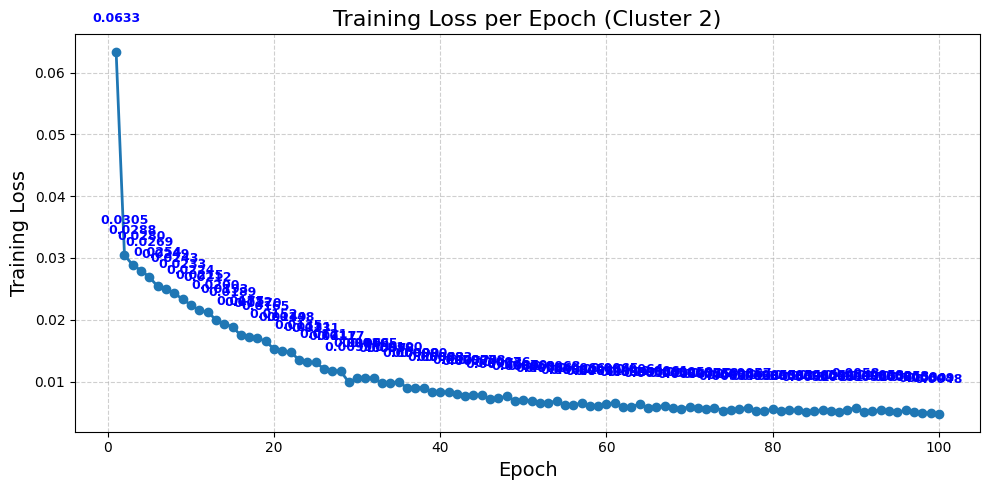

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with seed 123\models_\model2222


In [29]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 2 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_2.pkl", "rb") as f:
    X_cluster2 = pickle.load(f)

cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  seed 123\clustering_from_trainset\cluster_2_indices.npy")
y_cluster2 = train_dataset.y[cluster_2_indices]

if len(y_cluster2.shape) == 1:
    y_cluster2 = y_cluster2.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_2 = dc.data.NumpyDataset(X=np.array(X_cluster2), y=np.array(y_cluster2))

# === Model config
n_tasks = train_dataset_2.y.shape[1]
n_features = train_dataset_2.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_2 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with seed 123\models_\model2222"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_2.fit(train_dataset_2, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 2)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_2.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [31]:
# === Load cluster 2 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2.pkl", "rb") as f:
    X_test_cluster2 = pickle.load(f)

# === Load corresponding indices
test_cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_10656_CHNOS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster2 = test_dataset.y[test_cluster_2_indices]

if len(y_test_cluster2.shape) == 1:
    y_test_cluster2 = y_test_cluster2.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 2
test_dataset_2 = dc.data.NumpyDataset(X=np.array(X_test_cluster2), y=np.array(y_test_cluster2))

# === Predict using the trained model_2
predictions_2 = model_2.predict(test_dataset_2)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_2.shape)
print("Example prediction:", predictions_2[0])

evaluate_flat_predictions(predictions_2, test_dataset_2, itos, sf, cutoff=0.5)


✅ Prediction shape: (823, 3850, 2)
Example prediction: [[1.0000000e+00 7.3303998e-17]
 [1.0000000e+00 3.7202585e-15]
 [1.0000000e+00 2.1550926e-15]
 ...
 [1.0000000e+00 8.5566320e-13]
 [1.0000000e+00 1.8652631e-14]
 [4.4221037e-20 1.0000000e+00]]
[0] Pred: CCCCSC=1N=CN(C)C=1[N+1]([O-1])=O | True: CCCCSC=1N=CN(C)C=1[N+1]([O-1])=O | Tanimoto: 1.000
[1] Pred: CC1=NC2=C(SC(=S)N2C3=CC=CC=C3)C(=O)N1 | True: CC1=NC2=C(SC(=S)N2C3=CC=CC=C3)C(=O)N1 | Tanimoto: 1.000
[2] Pred: CC1=CC(=O)NC(=C1C#N)SCC#C | True: CC1=CC(=O)NC(=C1C#N)SCC#C | Tanimoto: 1.000
[3] Pred: CC(C)CSCCCCC=C | True: O=C1NSN=C1N2CCOCC2 | Tanimoto: 0.034
[4] Pred: C(C)SCC=C=CCCCC=C1CC=C=N1 | True: [O-1][N+1](=O)C1=CC=C2N(CCC2=C1)C(=O)CCSC=3SC4=NC=CC=C4N=3 | Tanimoto: 0.091
[5] Pred: C=CCCCCC | True: CCOC(=O)CSC1=NN=C(CN2N=NC(=N2)C3=CC=CC=C3)N1C | Tanimoto: 0.016
[6] Pred: CCOCNC=CC(S1)C1 | True: CCOC(=O)NC1=CC(NCCC2=CC=C(C=C2)[SH0](=O)(=O)N(CC)CC)=C3N=CC=NC3=N1 | Tanimoto: 0.052
[7] Pred: CCCCC=1CC(C)CC(S)SC=1C=O | True: CCOC(=O